In [1]:
import scipy.interpolate as spl
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
import scipy.integrate as spint
from scipy.optimize import curve_fit
import csv
import sys
sys.path.insert(1, '/Users/users/costa/Bulk/HC/project1/scripts')
import BayesLineFit_mod as blf

# Silk-Elmegreen (Boissier SFL) fitting

In [2]:
SFRD_file = '/Users/users/costa/Bulk/HC/project1/data/all_gals_Leroy08forHI_Frank16forH2.txt'

cols = ['gal', 'r_l08(kpc)', 'hi_l08(Msun/pc^2)', 'hi_err_l08(Msun/pc^2)', 'h2_f16_at_rl08(Msun/pc^2)', 'h2_err_f16_at_rl08(Msun/pc^2)', 'sfrd_l08(1e-4*Msun/yr/kpc^2)', 'sfrd_err_l08(1e-4*Msun/yr/kpc^2)']

sfrd_data = pd.read_csv(SFRD_file, sep=r"\s+", header=None, names=cols, comment="#", engine="python", dtype={"gal": "string"})

# print names of galaxies

sfrd_data["gal"] = sfrd_data["gal"].str.strip()
sfrd_gal_names = sfrd_data["gal"].unique().tolist()
print(sfrd_gal_names)

['DDO154', 'IC2574', 'NGC0925', 'NGC2403', 'NGC2841', 'NGC2976', 'NGC3198', 'NGC4736', 'NGC5055', 'NGC6946', 'NGC7331', 'NGC7793']


In [3]:
sfrd_data

,gal,r_l08(kpc),hi_l08(Msun/pc^2),hi_err_l08(Msun/pc^2),h2_f16_at_rl08(Msun/pc^2),h2_err_f16_at_rl08(Msun/pc^2),sfrd_l08(1e-4*Msun/yr/kpc^2),sfrd_err_l08(1e-4*Msun/yr/kpc^2)
0,DDO154,0.1,7.021416,0.673286,0.0,0.0,10.003113,2.116043
1,DDO154,0.3,6.925232,0.769470,0.0,0.0,9.426010,1.154205
2,DDO154,0.5,6.829048,0.673286,0.0,0.0,7.983253,1.250389
3,DDO154,0.7,6.540497,0.480919,0.0,0.0,6.348129,1.731308
4,DDO154,0.9,6.348129,0.384735,0.0,0.0,4.905373,1.538940
...,...,...,...,...,...,...,...,...
392,NGC7793,6.3,4.230207,0.571650,0.0,0.0,0.000000,1.143299
393,NGC7793,6.5,3.658558,0.457320,0.0,0.0,0.000000,1.143299
394,NGC7793,6.7,3.201238,0.342990,0.0,0.0,0.000000,1.143299
395,NGC7793,6.9,2.858248,0.342990,0.0,0.0,0.000000,1.143299


In [4]:
directory3 = "../data/allSFRprofs/"

rotcurves = {}  # galaxy -> DataFrame with R, Vrot, e_Vrot (and possibly old Σ)

for filename in os.listdir(directory3):
    if not filename.endswith(".txt"):
        continue

    filepath = os.path.join(directory3, filename)
    galaxy = os.path.splitext(filename)[0].split("_")[0].strip()

    df5 = pd.read_table(
        filepath,
        sep=r"\s+",
        engine="python",
        usecols=[
            "R[kpc]",
            "Vrot[km/s]",
            "e_Vrot[km/s]",
            "Sigma_gas[Msun/kpc2]",
            "e_Sigma_gas[Msun/kpc2]",
            "Sigma_SFR[Msun/yr/kpc2]",
            "e_Sigma_SFR[Msun/yr/kpc2]",
        ],
    )

    # clean + sort by radius
    df5 = df5.dropna(subset=["R[kpc]", "Vrot[km/s]"])
    df5 = df5.sort_values("R[kpc]")
    rotcurves[galaxy] = df5

In [5]:
# make sure galaxy names in sfrd_data are stripped
sfrd_data["gal"] = sfrd_data["gal"].str.strip()

def make_sigma_interp_log(R_data, Sigma_data, clamp_edges=True):
    """
    Log-space interpolator Σ(R) -> f(R_new), Σ in *positive* units.
    Outside the data range, holds log Σ flat at the edge values.
    
    If clamp_edges=True  : outside [R_min, R_max] keep log Σ fixed at edge values.
    If clamp_edges=False : outside [R_min, R_max] return NaN.
    
    Returns None if fewer than 2 valid points.
    """
    R_data  = np.asarray(R_data, float)
    Sigma_data = np.asarray(Sigma_data, float)

    mask = np.isfinite(R_data) & np.isfinite(Sigma_data) & (Sigma_data > 0)
    if mask.sum() < 2:
        return None

    R = R_data[mask]
    S = Sigma_data[mask]

    # sort by radius
    order = np.argsort(R)
    R = R[order]
    S = S[order]

    logS = np.log10(S)

    if clamp_edges:
        fill_value = (logS[0], logS[-1])
    else:
        # out of range -> NaN; these points can be dropped later
        fill_value = (np.nan, np.nan)
    
    f_log = interp1d(
        R, logS,
        kind="linear",
        bounds_error=False,
        fill_value=fill_value
    )

    def f(R_new):
        return 10.0**f_log(R_new)#np.clip(vals, 0.0, None)

    return f

rows = []

for gal, grp in sfrd_data.groupby("gal"):
    gal = str(gal)
    if gal not in rotcurves:
        # no rotation curve file for this galaxy → skip
        continue

    rc = rotcurves[gal]

    # OLD radii where we want everything
    R_old = rc["R[kpc]"].to_numpy(dtype=float)

    # NEW radii and corresponding Σ profiles
    r_new = grp["r_l08(kpc)"].to_numpy(dtype=float)
    order = np.argsort(r_new)
    r_new_sorted = r_new[order]

    hi_new      = grp["hi_l08(Msun/pc^2)"].to_numpy(dtype=float)[order]
    hi_err_new  = grp["hi_err_l08(Msun/pc^2)"].to_numpy(dtype=float)[order]
    h2_new      = grp["h2_f16_at_rl08(Msun/pc^2)"].to_numpy(dtype=float)[order]
    h2_err_new  = grp["h2_err_f16_at_rl08(Msun/pc^2)"].to_numpy(dtype=float)[order]
    sfr_new     = grp["sfrd_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(dtype=float)[order]
    sfr_err_new = grp["sfrd_err_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(dtype=float)[order]

    zero_mask = (sfr_new == 0.0)
    sfr_new[zero_mask] = np.nan
    sfr_err_new[zero_mask] = np.nan

    # interpolators for NEW HI, H2, SFR, and their errors
    f_hi      = make_sigma_interp_log(r_new_sorted, hi_new, clamp_edges=True)
    f_hi_err  = make_sigma_interp_log(r_new_sorted, hi_err_new, clamp_edges=True)
    f_h2      = make_sigma_interp_log(r_new_sorted, h2_new, clamp_edges=True)
    f_h2_err  = make_sigma_interp_log(r_new_sorted, h2_err_new, clamp_edges=True)
    f_sfr     = make_sigma_interp_log(r_new_sorted, sfr_new, clamp_edges=False)
    f_sfr_err = make_sigma_interp_log(r_new_sorted, sfr_err_new, clamp_edges=False)

    # if we don't have at least HI + H2 + SFR, skip this galaxy
    if f_hi is None or f_h2 is None or f_sfr is None:
        continue

    # evaluate at the OLD radii:
    hi_interp      = f_hi(R_old)
    hi_err_interp  = f_hi_err(R_old)   if f_hi_err  is not None else np.nan * R_old
    h2_interp      = f_h2(R_old)
    h2_err_interp  = f_h2_err(R_old)   if f_h2_err  is not None else np.nan * R_old
    sfr_interp     = f_sfr(R_old)
    sfr_err_interp = f_sfr_err(R_old)  if f_sfr_err is not None else np.nan * R_old

    df_comb = pd.DataFrame({
        "gal" : gal,
        "R[kpc]"       : R_old,
        "Vrot[km/s]"   : rc["Vrot[km/s]"].to_numpy(dtype=float),
        "e_Vrot[km/s]" : rc["e_Vrot[km/s]"].to_numpy(dtype=float),

        # NEW densities mapped onto the old radii:
        "hi_l08(Msun/pc^2)"             : hi_interp,
        "hi_err_l08(Msun/pc^2)"         : hi_err_interp,
        "h2_f16_at_rl08(Msun/pc^2)"     : h2_interp,
        "h2_err_f16_at_rl08(Msun/pc^2)" : h2_err_interp,
        "sfrd_l08(1e-4*Msun/yr/kpc^2)"  : sfr_interp,
        "sfrd_err_l08(1e-4*Msun/yr/kpc^2)" : sfr_err_interp,
    })

    rows.append(df_comb)

sfrd_on_rot = pd.concat(rows, ignore_index=True)
sfrd_on_rot.to_csv("../data/sfrd_with_interpolated_vrot.csv", index=False)

In [6]:
sfrd_on_rot

,gal,R[kpc],Vrot[km/s],e_Vrot[km/s],hi_l08(Msun/pc^2),hi_err_l08(Msun/pc^2),h2_f16_at_rl08(Msun/pc^2),h2_err_f16_at_rl08(Msun/pc^2),sfrd_l08(1e-4*Msun/yr/kpc^2),sfrd_err_l08(1e-4*Msun/yr/kpc^2)
0,NGC0925,0.200713,17.247000,3.720000,10.033235,0.652072,3.448329,0.763755,182.805941,30.986684
1,NGC0925,0.602138,17.248144,3.720145,10.759190,1.137569,2.909646,0.644445,128.262706,21.046063
2,NGC0925,1.003563,20.576380,4.141542,11.141178,1.099893,2.728299,0.604279,92.205551,13.420030
3,NGC0925,1.404989,26.579831,4.174999,10.883729,1.042285,2.552118,0.565257,67.041223,8.950803
4,NGC0925,1.806414,34.358248,2.655898,10.883361,1.042285,2.348633,0.520188,52.844810,9.126959
...,...,...,...,...,...,...,...,...,...,...
465,NGC7331,22.877000,241.574000,4.593000,3.080865,0.363622,0.008721,0.001882,NaN,NaN
466,NGC7331,23.305000,241.574000,4.593000,2.913725,0.323747,0.007228,0.001560,NaN,NaN
467,NGC7331,23.733000,241.574000,4.593000,2.913725,0.323747,0.007228,0.001560,NaN,NaN
468,NGC7331,24.160000,241.574000,4.593000,2.913725,0.323747,0.007228,0.001560,NaN,NaN


In [7]:
v_sesfl = sfrd_on_rot["Vrot[km/s]"].to_numpy(float) # in km/s
v_err_sesfl = sfrd_on_rot["e_Vrot[km/s]"].to_numpy(float) # in km/s
r_sesfl = sfrd_on_rot["R[kpc]"].to_numpy(float) # in kpc

sigma_hi = sfrd_on_rot["hi_l08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2
sigma_h2 = sfrd_on_rot["h2_f16_at_rl08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2

sigma_hi_err = sfrd_on_rot["hi_err_l08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2
sigma_h2_err = sfrd_on_rot["h2_err_f16_at_rl08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2

sigma_gas_sesfl = (sigma_hi + sigma_h2) * 1e6 # Msun/kpc^2
sigma_gas_err_sesfl = np.sqrt(sigma_hi_err**2 + sigma_h2_err**2)*1e6 # Msun/kpc^2

sigma_sfr_sesfl = sfrd_on_rot["sfrd_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float) * 1e-4 # Msun/yr/kpc^2
sigma_sfr_err_sesfl = sfrd_on_rot["sfrd_err_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float) * 1e-4 # Msun/yr/kpc^2

omega_sesfl = (v_sesfl/r_sesfl)*1.022e-9 # in units of yr^-1 if r_sesfl is in kpc and v_sesfl in km/s
omega_err_sesfl = (v_err_sesfl/r_sesfl)*1.022e-9

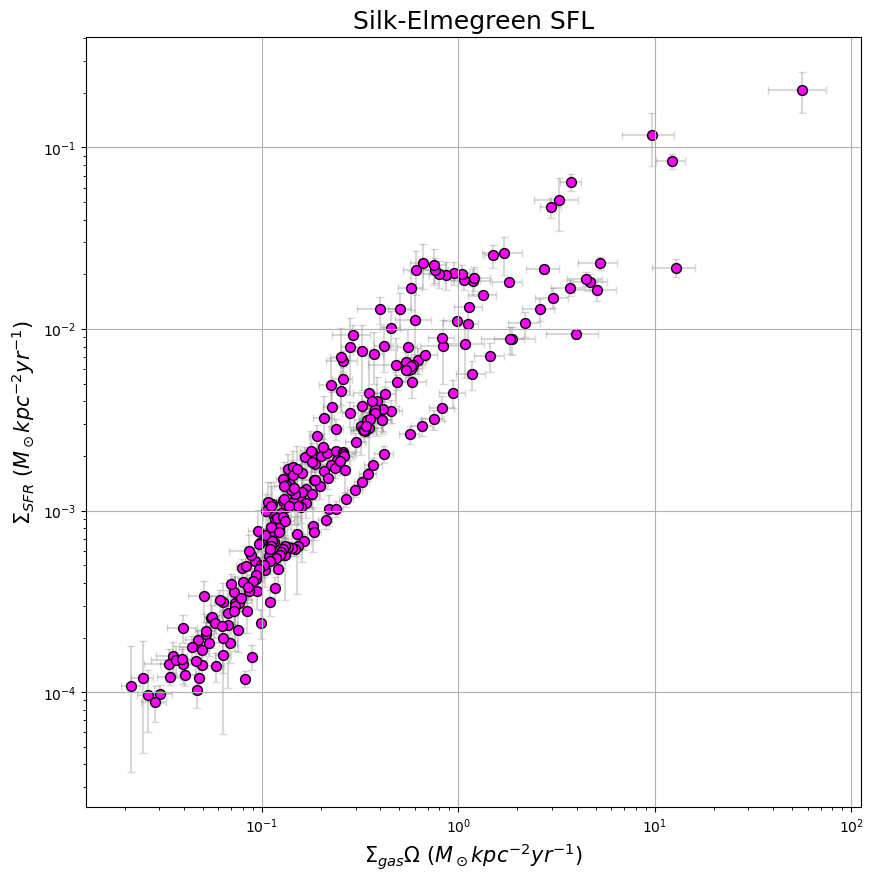

In [8]:
fig = figure(figsize=(10,10), facecolor='w')
frame = fig.add_subplot(1,1,1)
frame.scatter(sigma_gas_sesfl*omega_sesfl, sigma_sfr_sesfl, color="magenta", edgecolor='k', s=50)
frame.errorbar(sigma_gas_sesfl*omega_sesfl, sigma_sfr_sesfl, xerr=sigma_gas_sesfl*omega_sesfl*np.sqrt((sigma_gas_err_sesfl/sigma_gas_sesfl)**2 + (omega_err_sesfl/omega_sesfl)**2), yerr=sigma_sfr_err_sesfl, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.set_xscale('log')
frame.set_yscale('log')
frame.set_title(r"Silk-Elmegreen SFL", fontsize = 18)
frame.set_xlabel(r"$\Sigma_{gas}\Omega$ $(M_\odot kpc^{-2} yr^{-1})$", fontsize = 15)
frame.set_ylabel(r"$\Sigma_{SFR}$ $(M_\odot kpc^{-2} yr^{-1})$", fontsize = 15)
frame.grid()
show()

In [9]:
#First masking

mask = np.isfinite(sigma_gas_sesfl) & np.isfinite(sigma_sfr_sesfl) & np.isfinite(omega_sesfl) & (sigma_sfr_sesfl != 0) & (sigma_sfr_err_sesfl != 0)
masked_sigma_sfr_sesfl = sigma_sfr_sesfl[mask]*1e-6 #turn it from kpc^-2 to pc^-2
masked_sigma_sfr_err_sesfl = sigma_sfr_err_sesfl[mask]*1e-6
masked_sigma_gas_sesfl = sigma_gas_sesfl[mask]*1e-6
masked_sigma_gas_err_sesfl = sigma_gas_err_sesfl[mask]*1e-6
masked_omega_sesfl = omega_sesfl[mask]
masked_omega_err_sesfl = omega_err_sesfl[mask]

In [10]:
def fit_se(x, a, n):
    return a * (x**n)

x_combined = np.array([masked_sigma_gas_sesfl, masked_omega_sesfl])

popt, pcov = curve_fit(fit_se, masked_sigma_gas_sesfl, masked_sigma_sfr_sesfl/masked_omega_sesfl, p0=[4.5e-6, 2])
#, sigma=(masked_sigma_sfr_sesfl/masked_omega_sesfl*np.sqrt((masked_sigma_sfr_err_sesfl/masked_sigma_sfr_sesfl)**2 + (masked_omega_err_sesfl/masked_omega_sesfl)**2))
a_sesfl, n_sesfl = popt
print(a_sesfl, n_sesfl)

0.0233712744682335 0.6466116680262644


In [11]:
NGC5055 = pd.read_table("../data/allSFRprofs/NGC5055_R_Vrot_SigmaGas_SigmaSFR.txt", sep=" ", usecols=["R[kpc]", "Vrot[km/s]", "e_Vrot[km/s]", "Sigma_gas[Msun/kpc2]", "e_Sigma_gas[Msun/kpc2]", "Sigma_SFR[Msun/yr/kpc2]", "e_Sigma_SFR[Msun/yr/kpc2]"])

NGC5055_r = pd.to_numeric(NGC5055['R[kpc]'], errors='coerce')
NGC5055_vrot = pd.to_numeric(NGC5055['Vrot[km/s]'], errors='coerce')
NGC5055_evrot = pd.to_numeric(NGC5055['e_Vrot[km/s]'], errors='coerce')
NGC5055_sgas = pd.to_numeric(NGC5055['Sigma_gas[Msun/kpc2]'], errors='coerce')*1e-6
NGC5055_esgas = pd.to_numeric(NGC5055['e_Sigma_gas[Msun/kpc2]'], errors='coerce')*1e-6
NGC5055_ssfr = pd.to_numeric(NGC5055['Sigma_SFR[Msun/yr/kpc2]'], errors='coerce')*1e-6
NGC5055_essfr = pd.to_numeric(NGC5055['e_Sigma_SFR[Msun/yr/kpc2]'], errors='coerce')*1e-6

NGC5055_omega = (NGC5055_vrot/NGC5055_r)*1.022e-9
NGC5055_eomega = (NGC5055_evrot/NGC5055_r)*1.022e-9

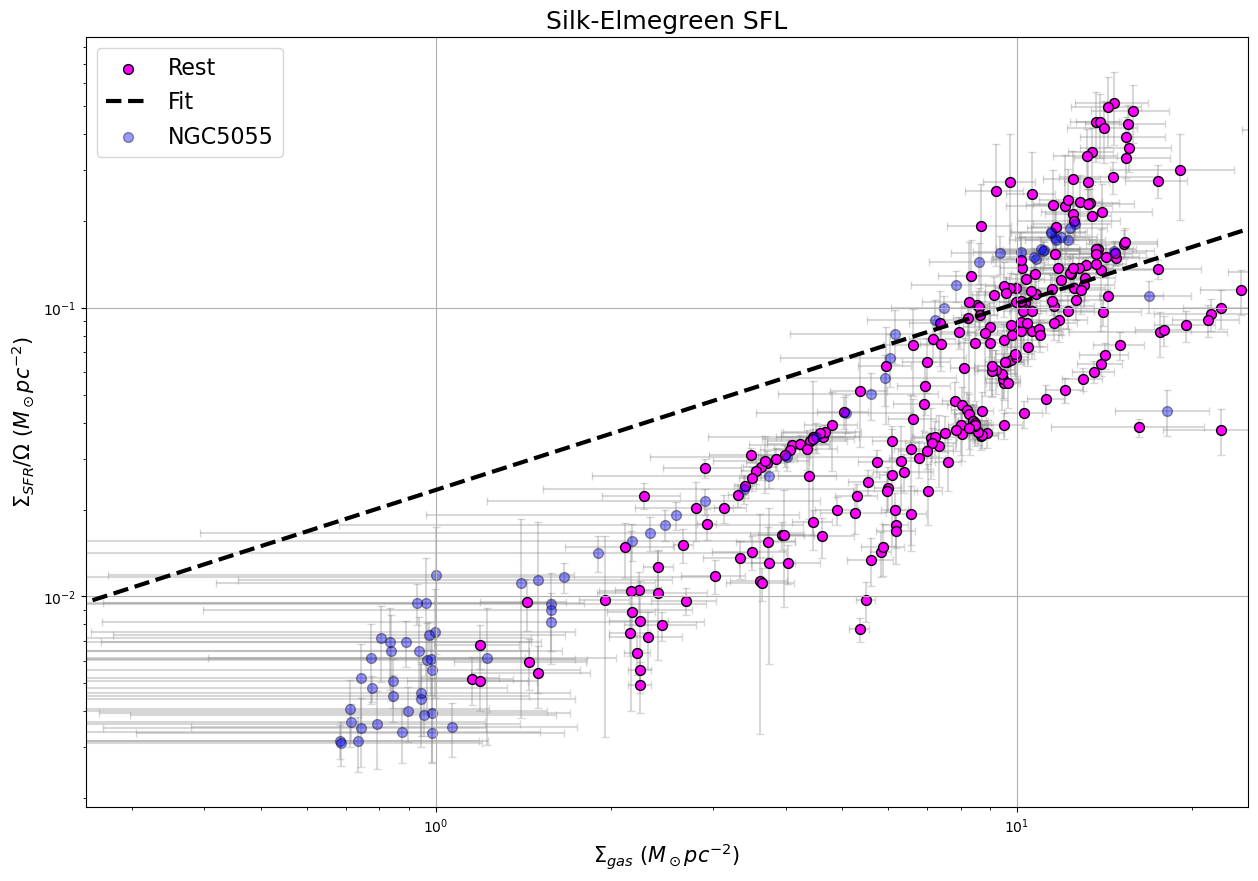

In [12]:
sigma_gas_lin = np.linspace(2e-1, 3e1, 100)

fig = figure(figsize=(15,10), facecolor='w')
frame = fig.add_subplot(1,1,1)
frame.scatter(masked_sigma_gas_sesfl, masked_sigma_sfr_sesfl/masked_omega_sesfl, color="magenta", edgecolor='k', s=50, label="Rest")
frame.errorbar(masked_sigma_gas_sesfl, masked_sigma_sfr_sesfl/masked_omega_sesfl, xerr=masked_sigma_gas_err_sesfl, yerr=masked_sigma_sfr_sesfl/masked_omega_sesfl*np.sqrt((masked_sigma_sfr_err_sesfl/masked_sigma_sfr_sesfl)**2 + (masked_omega_err_sesfl/masked_omega_sesfl)**2), fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.plot(sigma_gas_lin, fit_se(sigma_gas_lin, a_sesfl, n_sesfl), color="k", lw=3, ls="dashed", label="Fit")
frame.scatter(NGC5055_sgas, NGC5055_ssfr/NGC5055_omega, color="blue", edgecolor='k', s=50, alpha=0.4, label="NGC5055")
frame.errorbar(NGC5055_sgas, NGC5055_ssfr/NGC5055_omega, xerr=NGC5055_esgas, yerr=NGC5055_ssfr/NGC5055_omega*np.sqrt((NGC5055_essfr/NGC5055_ssfr)**2 + (NGC5055_eomega/NGC5055_omega)**2), fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.set_xscale('log')
frame.set_yscale('log')
frame.set_xlim(2.5e-1, 2.5e1)
frame.set_title(r"Silk-Elmegreen SFL", fontsize = 18)
frame.set_xlabel(r"$\Sigma_{gas}$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.set_ylabel(r"$\Sigma_{SFR}/\Omega$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.legend(prop={'size': 16})
frame.grid()
show()

In [ ]:
log_sgas = np.log10(1.4*masked_sigma_gas_sesfl)
log_esgas = (1/np.log(10))*(masked_sigma_gas_err_sesfl/masked_sigma_gas_sesfl)
log_y = np.log10(masked_sigma_sfr_sesfl/masked_omega_sesfl)
log_ey = (1/np.log(10))*((masked_sigma_sfr_sesfl/masked_omega_sesfl*np.sqrt((masked_sigma_sfr_err_sesfl/masked_sigma_sfr_sesfl)**2 + (masked_omega_err_sesfl/masked_omega_sesfl)**2))/(masked_sigma_sfr_sesfl/masked_omega_sesfl))
#print(log_sgas)

In [14]:
def lin2(x, a, b):
    return a*x + b

popt, pcov = curve_fit(lin2, log_sgas, log_y, sigma=log_ey, p0=[4, -4])
a_2, b_2 = popt
#print(a_2, b_2)
print(f"a = {10**b_2}, n = {a_2}")

a = 0.003778947114732477, n = 1.1276961589763626


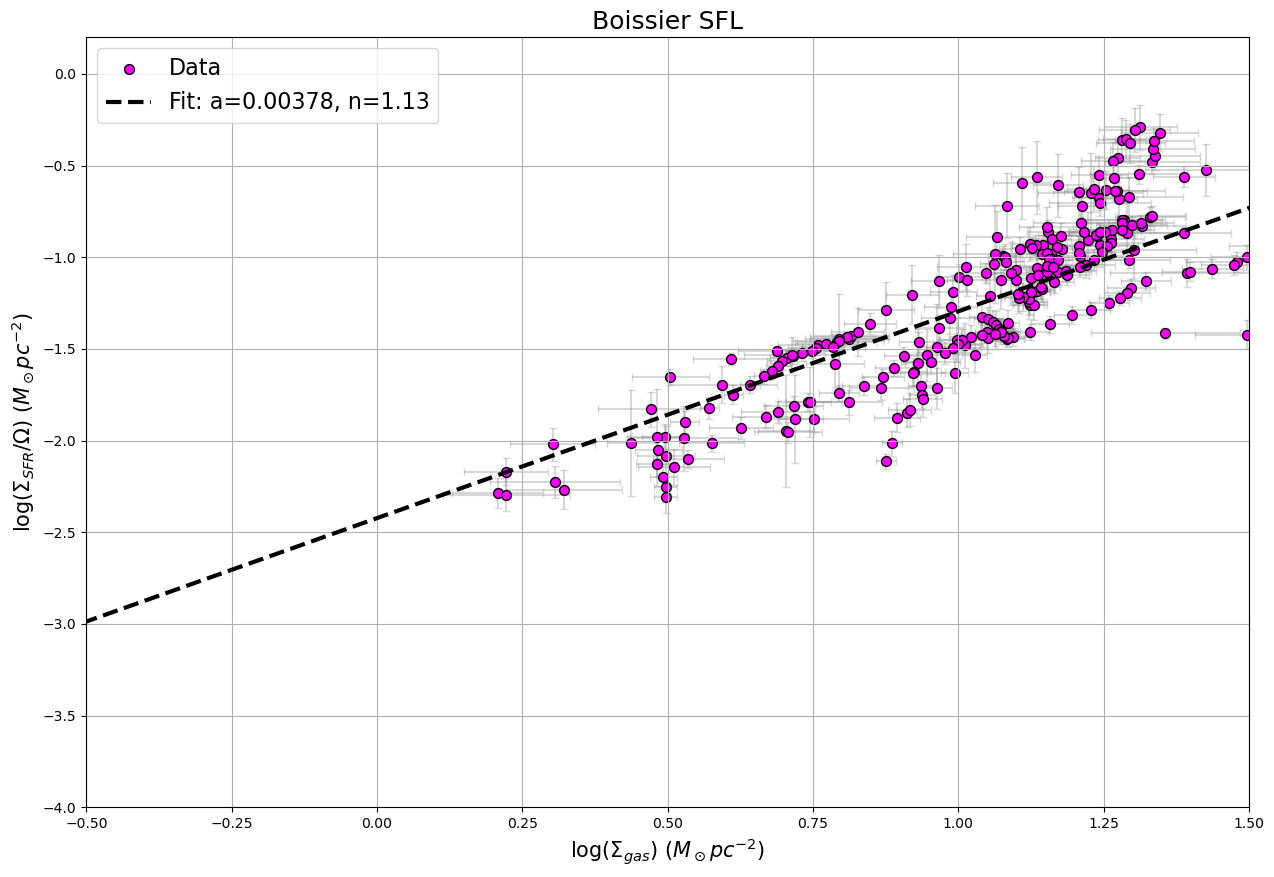

In [15]:
fig = figure(figsize=(15,10), facecolor='w')
frame = fig.add_subplot(1,1,1)
frame.scatter(log_sgas, log_y, color="magenta", edgecolor='k', s=50, label="Data")
frame.errorbar(log_sgas, log_y, xerr=log_esgas, yerr=log_ey, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.plot(np.linspace(-1, 2, 50), lin2(np.linspace(-1, 2, 50), a_2, b_2), color="k", lw=3, ls="dashed", label=f"Fit: a={10**b_2:.5f}, n={a_2:.2f}")
#frame.set_xscale('log')
#frame.set_yscale('log')
frame.set_xlim(-0.5, 1.5)
frame.set_ylim(-4, 0.2)
frame.set_title(r"Boissier SFL", fontsize = 18)
frame.set_xlabel(r"log$(\Sigma_{gas})$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.set_ylabel(r"log$(\Sigma_{SFR}/\Omega)$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.legend(prop={'size': 16})
frame.grid()
show()

Number of data points: 266
-------------------------
PEARSON'S TEST
Correlation coefficient: 0.8406; p-value 2.854e-72
-------------------------
SPEARMAN'S TEST
Correlation coefficient: 0.8816; p-value 4.599e-88
-------------------------
KENDALL'S TEST
Correlation coefficient: 0.7069; p-value 3.647e-66
-------------------------
Running MCMC with 128 cores. Please wait...
Converged after 4000 iterations in 26 seconds
Mean acceptance fraction: 0.642
-------------------------
Maximum likelihood (ML) value: 144.3
Slope (ML, median, upper error, lower error): 1.641; 1.649; +0.06673, -0.06291
Intercept (ML, median, upper error, lower error): -2.973; -2.982; +0.06822; -0.07331
Intrinsic scatter (ML, median, upper error, lower error): 0.1213; 0.1228; +0.007195; -0.006793
ML observed scatter (vertical): 0.2775
ML observed scatter (orthogonal): 0.1444
*** NB medians and errors only meaningful for unimodal posteriors. Check the corner plot! ***
-------------------------


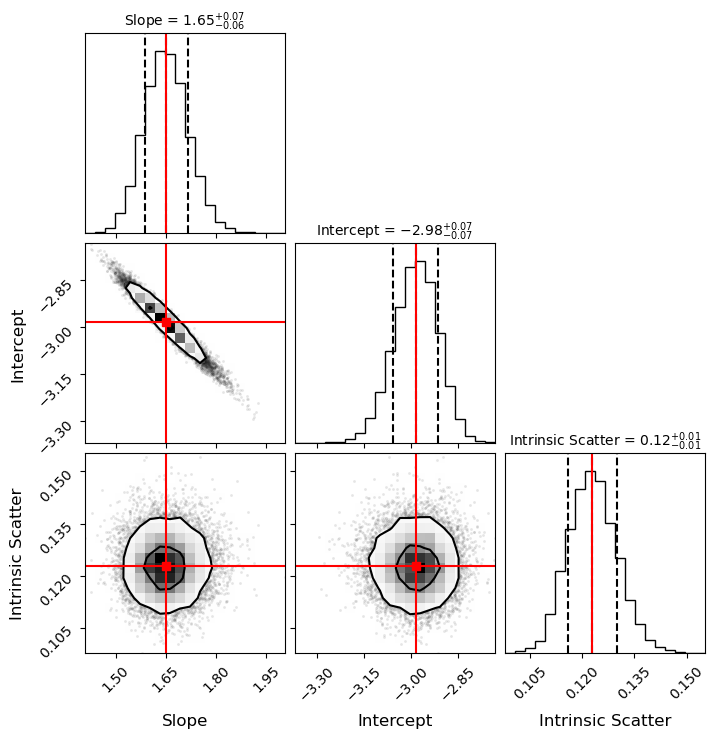

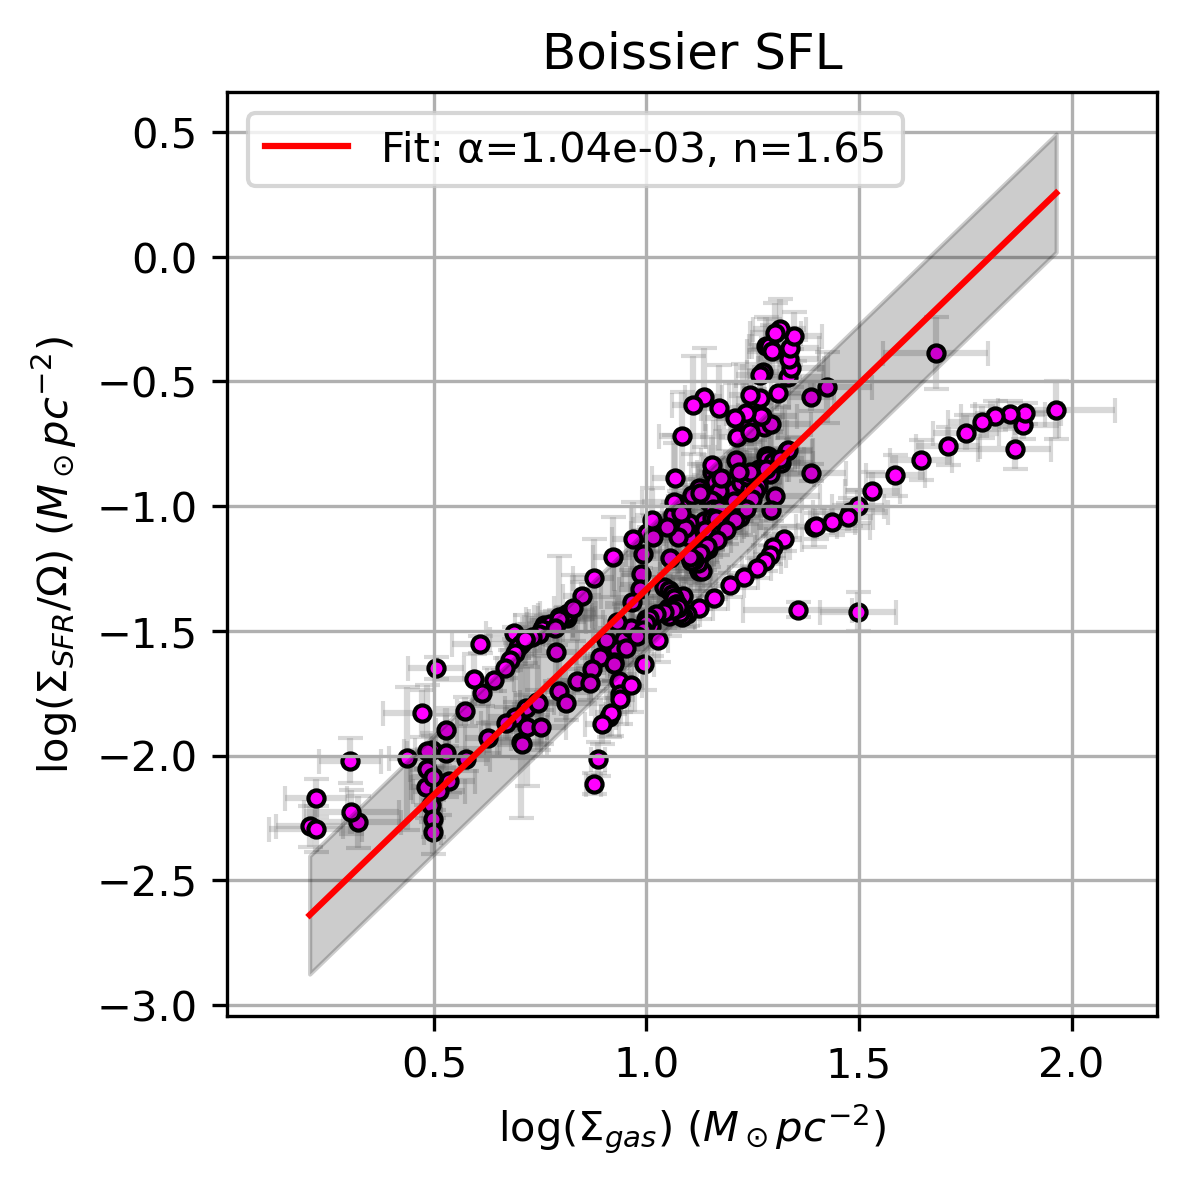

In [16]:
a, b, s, sobs = blf.BayesLineFit(log_sgas, log_y, log_esgas, log_ey, outfile_chain=None, 
                                 outfile_bestfit=None, outplot_convergence=None, plotpdf=False,
                                plot_title="boissier")

# Kennicutt-Schmidt SFL fitting

In [17]:
log_sfr = np.log10(masked_sigma_sfr_sesfl*1e9)
log_esfr = (1/np.log(10))*(masked_sigma_sfr_err_sesfl/masked_sigma_sfr_sesfl)

In [18]:
popt, pcov = curve_fit(lin2, log_sgas, log_sfr, p0=[4, -4])
a_ksl, b_ksl = popt
#print(a_ksl, b_ksl)
print(f"a = {10**b_ksl}, n = {a_ksl}")

a = 0.026599979930128085, n = 1.6928837588244323


Number of data points: 266
-------------------------
PEARSON'S TEST
Correlation coefficient: 0.7717; p-value 8.23e-54
-------------------------
SPEARMAN'S TEST
Correlation coefficient: 0.824; p-value 4.335e-67
-------------------------
KENDALL'S TEST
Correlation coefficient: 0.6354; p-value 8.298e-54
-------------------------
Running MCMC with 128 cores. Please wait...


Converged after 4100 iterations in 23 seconds
Mean acceptance fraction: 0.641
-------------------------
Maximum likelihood (ML) value: 73.47
Slope (ML, median, upper error, lower error): 2.69; 2.717; +0.1435, -0.1346
Intercept (ML, median, upper error, lower error): -2.641; -2.667; +0.1431; -0.158
Intrinsic scatter (ML, median, upper error, lower error): 0.1724; 0.1737; +0.008903; -0.008202
ML observed scatter (vertical): 0.5311
ML observed scatter (orthogonal): 0.185
*** NB medians and errors only meaningful for unimodal posteriors. Check the corner plot! ***
-------------------------


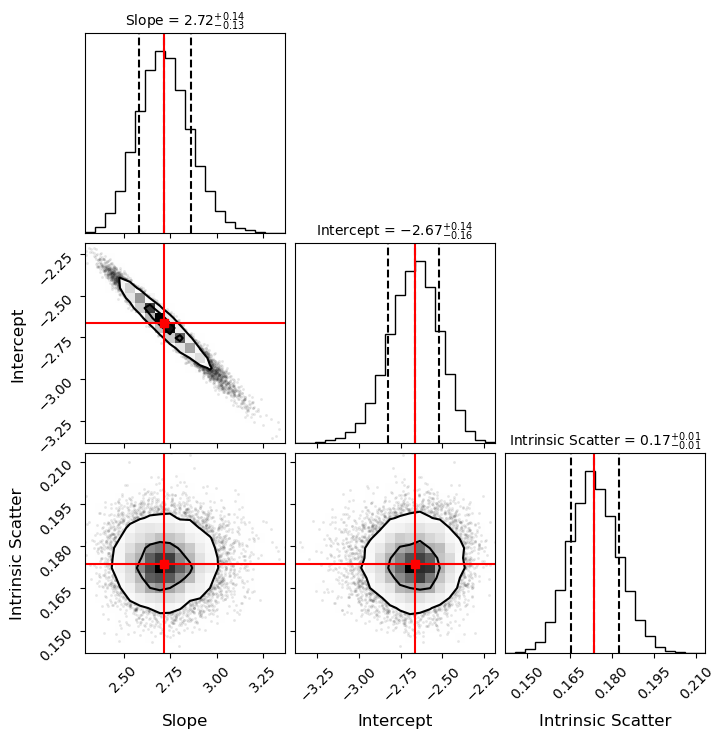

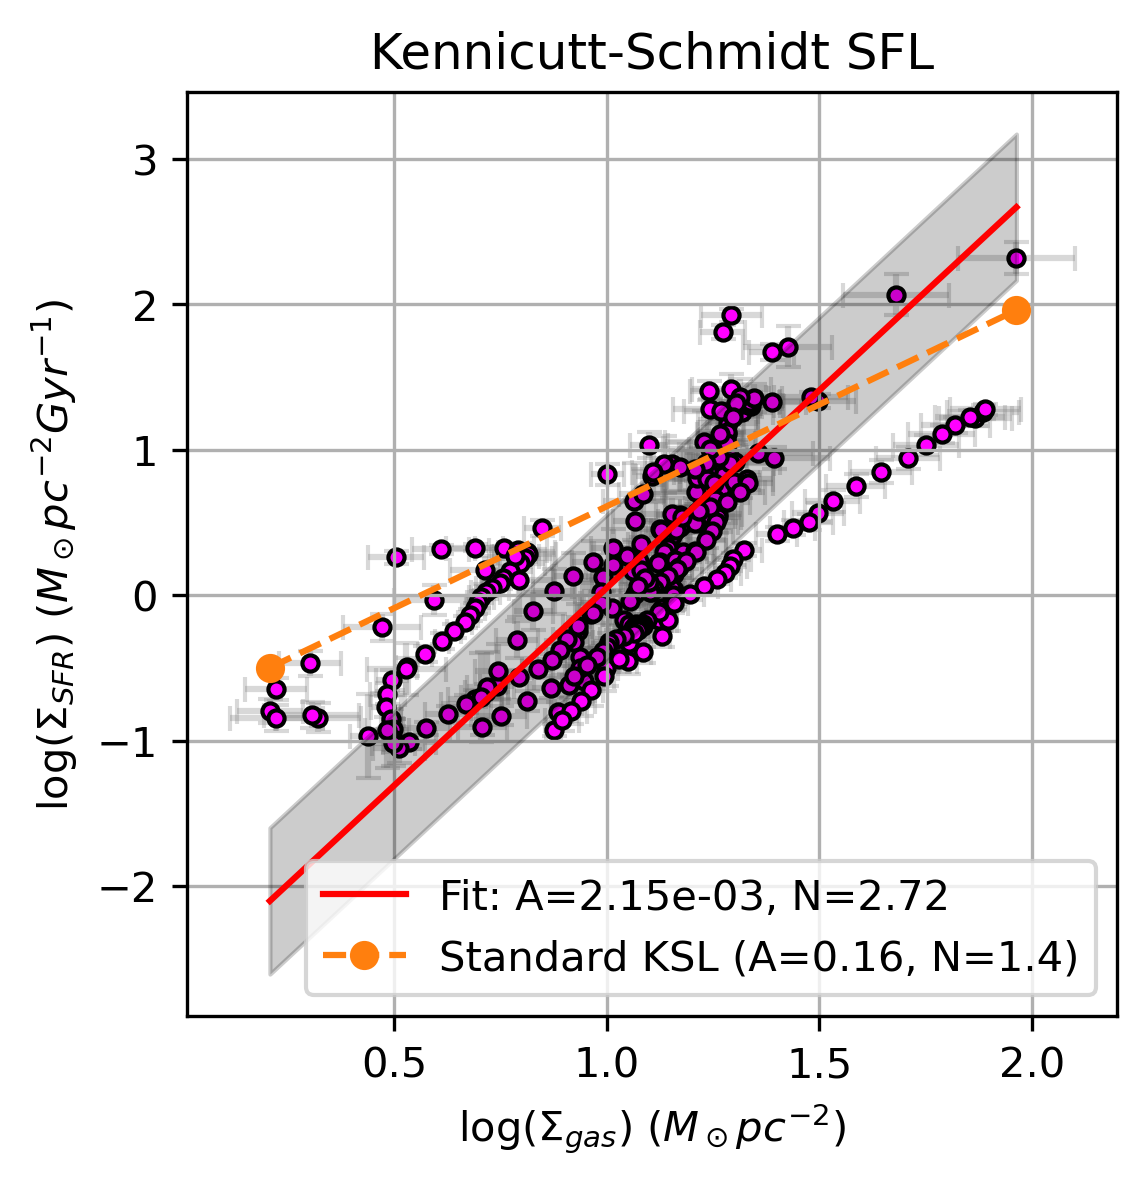

In [19]:
a, b, s, sobs = blf.BayesLineFit(log_sgas, log_sfr, log_esgas, log_esfr, outfile_chain=None, 
                                 outfile_bestfit=None, outplot_convergence=None, plotpdf=False,
                                plot_title="kennicutt")

In [28]:
#what galaxies are in log_sgas
masked_indices = np.where(mask)[0]
logged_galaxies = sfrd_on_rot["gal"].to_numpy(dtype=str)[masked_indices]
unique_logged_galaxies = np.unique(logged_galaxies)
print(unique_logged_galaxies)

['NGC0925' 'NGC2403' 'NGC2841' 'NGC2976' 'NGC3198' 'NGC4736' 'NGC5055'
 'NGC6946' 'NGC7331']


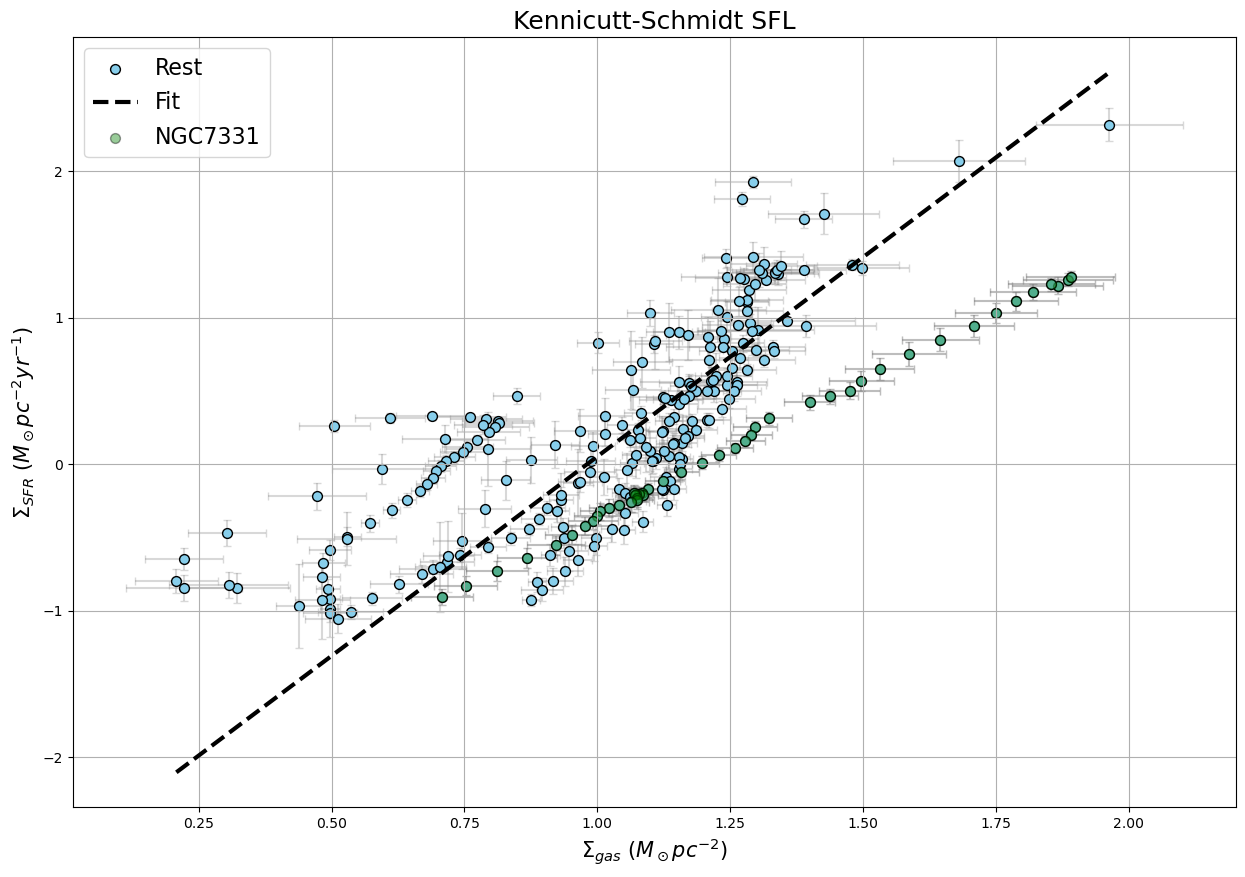

In [33]:
# show KSL with NGC 7331 (from new interpolated file!!) data colored with another color
# the data must come from sfrd_on_rot
NGC7331_data = sfrd_on_rot[sfrd_on_rot["gal"] == "NGC7331"]
NGC7331_sgas = (NGC7331_data["hi_l08(Msun/pc^2)"].to_numpy(float) + NGC7331_data["h2_f16_at_rl08(Msun/pc^2)"].to_numpy(float))
NGC7331_esgas = np.sqrt(NGC7331_data["hi_err_l08(Msun/pc^2)"].to_numpy(float)**2 + NGC7331_data["h2_err_f16_at_rl08(Msun/pc^2)"].to_numpy(float)**2)
NGC7331_ssfr = NGC7331_data["sfrd_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float)*1e-4*1e-6 # Msun/yr/kpc^2 to Msun/yr/pc^2
NGC7331_essfr = NGC7331_data["sfrd_err_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float)*1e-4*1e-6

# convert NGC7331 data in the same way as log_sgas and log_sfr
log_NGC7331_sgas = np.log10(1.4*NGC7331_sgas)
log_NGC7331_esgas = (1/np.log(10))*(NGC7331_esgas/NGC7331_sgas)


log_NGC7331_ssfr = np.log10(NGC7331_ssfr*1e9)
log_NGC7331_essfr = (1/np.log(10))*(NGC7331_essfr/NGC7331_ssfr)

# function to fit linear line in log-log space
def fit_log(x, a, n):
    return np.log10(a) + n*x

fig = figure(figsize=(15,10), facecolor='w')
frame = fig.add_subplot(1,1,1)
frame.scatter(log_sgas, log_sfr, color="skyblue", edgecolor='k', s=50, label="Rest")
frame.errorbar(log_sgas, log_sfr, xerr=log_esgas, yerr=log_esfr, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.plot(np.linspace(np.min(log_sgas), np.max(log_sgas), 10), fit_log(np.linspace(np.min(log_sgas), np.max(log_sgas), 10), 2.15e-3, 2.72), color="k", lw=3, ls="dashed", label="Fit")
frame.scatter(log_NGC7331_sgas, log_NGC7331_ssfr, color="green", edgecolor='k', s=50, alpha=0.4, label="NGC7331")
frame.errorbar(log_NGC7331_sgas, log_NGC7331_ssfr, xerr=log_NGC7331_esgas, yerr=log_NGC7331_essfr, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.set_title(r"Kennicutt-Schmidt SFL", fontsize = 18)
frame.set_xlabel(r"$\Sigma_{gas}$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.set_ylabel(r"$\Sigma_{SFR}$ $(M_\odot pc^{-2} yr^{-1})$", fontsize = 15)
frame.legend(prop={'size': 16})
frame.grid()
show()

1.4194744009899496


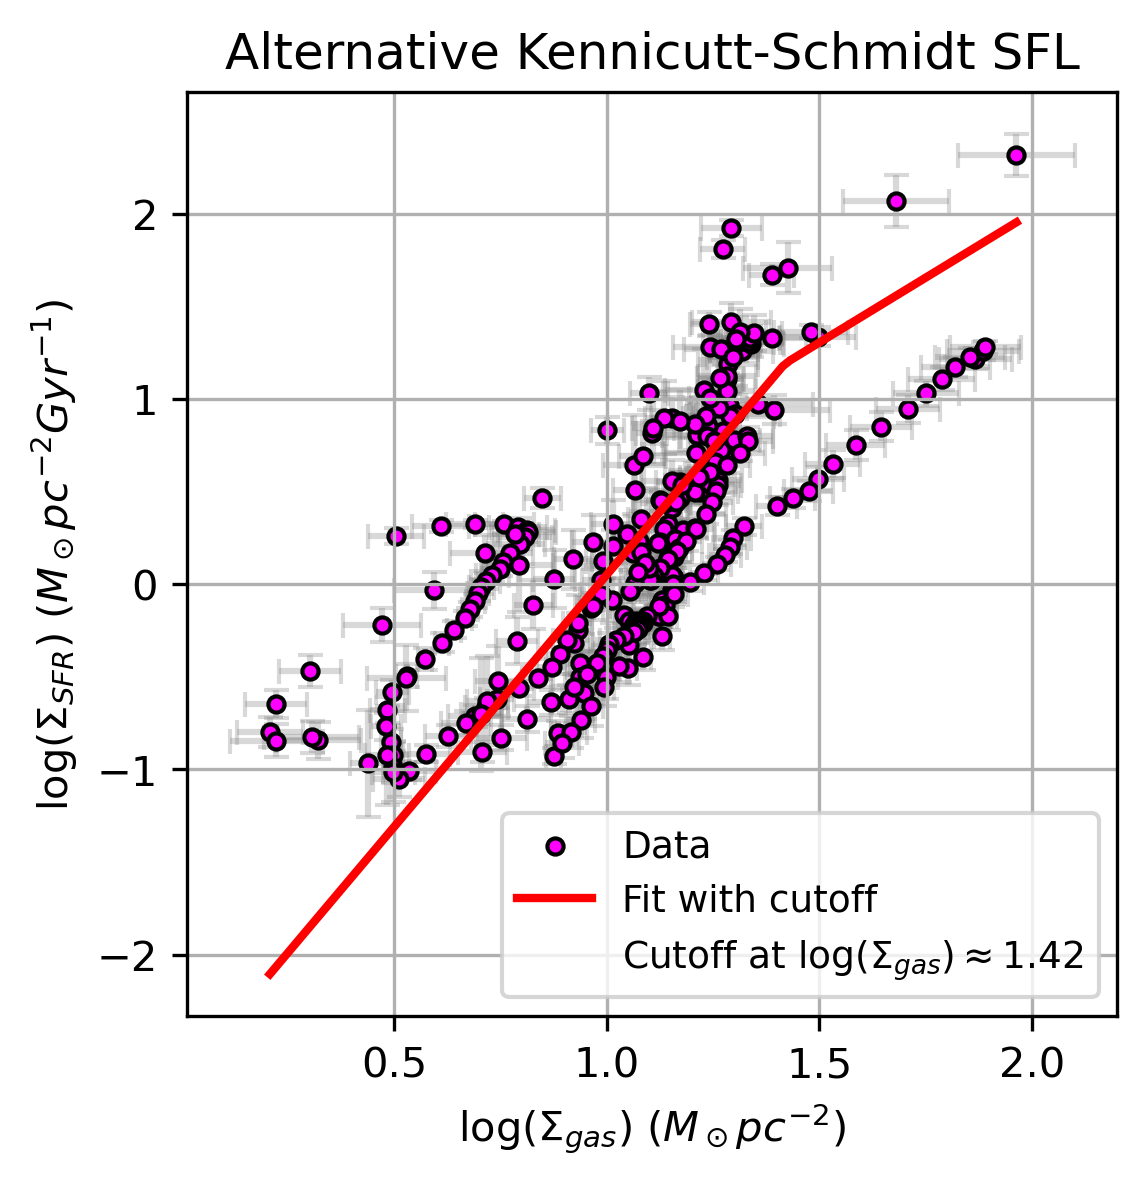

In [31]:
def new_SFL(x, m_new, b_new, x_cut=1.02391, m_old=1.4):
    # follow new KSL until x=1, then follow old KSL. Need to find intercept so both are equal at x_cut
    b_old = b_new + (m_new - m_old) * x_cut

    y = m_new * x + b_new
    mask = x > x_cut
    y[mask] = m_old * x[mask] + b_old
    return y

def intersection_x(m1, b1, m2, b2):
    return (b2 - b1)/(m1 - m2)

xii = np.linspace(np.min(log_sgas), np.max(log_sgas), 100)

inters = intersection_x(2.72, np.log10(2.14e-3), 1.4, np.log10(0.16))
print(inters)

fig = figure(figsize=(4,4), dpi=300, facecolor='w')
frame = fig.add_subplot(1,1,1)
frame.scatter(log_sgas, log_sfr, color="magenta", edgecolor='k', linewidth=1, s=15, zorder=1, label="Data")
frame.errorbar(log_sgas, log_sfr, xerr=log_esgas, yerr=log_esfr, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
#frame.plot(np.linspace(-0.5, 1.5, 2), lin2(np.linspace(-0.5, 1.5, 2), 1.4, np.log10(0.16)), "--o", zorder=4, label=f"Standard KSL")
frame.plot(xii, new_SFL(xii, 2.72, np.log10(2.14e-3), x_cut=inters), lw=2, color="r", zorder=4, label=f"Fit with cutoff")
frame.plot([], [], ' ', label=r"Cutoff at log$(\Sigma_{{gas}})\approx ${:.2f}".format(inters))
frame.set_title(r"Alternative Kennicutt-Schmidt SFL")
frame.set_xlabel(r"log$(\Sigma_{gas})$ $(M_\odot pc^{-2})$")
frame.set_ylabel(r"log$(\Sigma_{SFR})$ $(M_\odot pc^{-2} Gyr^{-1})$")
frame.legend(prop={'size': 9})
frame.grid()
show()